In [1]:
from pathlib import Path
from IPython.display import HTML, display
css = Path("../../../css/rtl.css").read_text(encoding="utf-8")
display(HTML(f"<style>{css}</style>"))

# فصل ۸ — یادگیری مبتنی بر نمونه
## درس ۷: رگرسیون KNN و بایاس/واریانس هموارسازی محلی

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")

KNN فقط برای پیش‌بینی دسته نیست. در رگرسیون، یک مقدار پیوسته را با تجمیع هدف‌های مشاهده‌های نزدیک پیش‌بینی می‌کند. رگرسیون KNN یکنواخت میانگین هدف‌های $k$ همسایه را می‌گیرد و رگرسیون وزن‌دار بر حسب فاصله به هدف‌های نزدیک‌تر اثر بیشتری می‌دهد. نتیجه یک هموارساز محلی منعطف است: پیش‌بینی به‌جای برازش یک معادلهٔ سراسری، با مشاهده‌های پیرامون هر پرس‌وجو سازگار می‌شود.

پرسش اصلی دوباره اندازهٔ همسایگی است. K بسیار کوچک تغییر محلی را دقیق دنبال و به نویز واکنش می‌دهد. K بزرگ به‌طور گسترده میانگین می‌گیرد و منحنی پایدار و هموار می‌سازد، اما تغییر محلی واقعی را از دست می‌دهد. این شکل هموارسازی مصالحهٔ بایاس-واریانس است. آن را روی منحنی مصنوعی می‌بینیم، K را برای رگرسیون Wine Quality با اعتبارسنجی انتخاب می‌کنیم، قانون‌های وزن‌دهی را مقایسه می‌کنیم، residual را بررسی و همسایه‌های پشت یک پیش‌بینی را می‌بینیم.

Wine_Quality.csv اندازه‌گیری‌های شیمیایی عددی و امتیاز کیفیت صحیح دارد. با وجود گسسته‌بودن quality، رفتار با آن به‌عنوان هدف پیوستهٔ مرتب، نمایش مفیدی از رگرسیون است. خروجی باید امتیاز برآوردی تفسیر شود، نه توصیهٔ پزشکی، تجاری یا حسی.

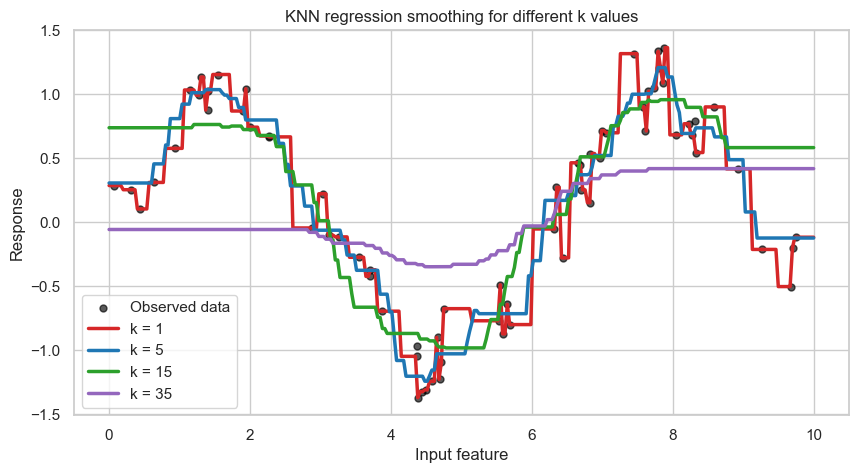

In [3]:
x_train = np.sort(rng.uniform(0, 10, 70))
y_train = np.sin(x_train) + 0.25 * rng.normal(size=x_train.size)
x_grid = np.linspace(0, 10, 300)
k_values = [1, 5, 15, 35]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(x_train, y_train, color="black", s=25, alpha=0.65, label="Observed data")
for k_value, color in zip(k_values, ["tab:red", "tab:blue", "tab:green", "tab:purple"]):
    model = KNeighborsRegressor(n_neighbors=k_value, weights="uniform").fit(x_train.reshape(-1, 1), y_train)
    ax.plot(x_grid, model.predict(x_grid.reshape(-1, 1)), color=color, linewidth=2.5, label=f"k = {k_value}")
ax.set_xlabel("Input feature")
ax.set_ylabel("Response")
ax.set_title("KNN regression smoothing for different k values")
ax.legend()
plt.show()

### هدف‌های یادگیری

در پایان این درس باید بتوانید:

1. توضیح دهید رگرسیون KNN چگونه هدف‌های همسایه را تجمیع می‌کند.
2. رگرسیون KNN یکنواخت و وزن‌دار بر حسب فاصله را جدا کنید.
3. K کوچک و بزرگ را به بایاس و واریانس هموارسازی محلی مرتبط کنید.
4. K را با اعتبارسنجی فقط روی آموزش و RMSE انتخاب کنید.
5. پیش‌بینی پیوسته را با MAE، RMSE و $R^2$ ارزیابی کنید.
6. از نمودار actual-versus-predicted و residual برای تشخیص رگرسور استفاده کنید.
7. همسایه‌ها و فاصله‌های مؤثر بر یک پیش‌بینی پیوسته را بازرسی کنید.
8. محدودیت‌های interpolation، extrapolation، مقیاس، تراکم و محاسبه را تشخیص دهید.

رگرسیون KNN زمانی مفید است که مثال‌های نزدیک انتظار می‌رود خروجی مشابه داشته باشند و میانگین محلی از یک رابطهٔ سراسری واحد معقول‌تر باشد.

In [4]:
wine_path = Path("../../../Datasets/Classification/Wine_Quality.csv")
wine = pd.read_csv(wine_path).sample(n=1200, random_state=RANDOM_STATE).reset_index(drop=True)
wine_X = wine.drop(columns="quality")
wine_y = wine["quality"]

display(wine.head())
display(wine.dtypes.rename("dtype").to_frame())
display(wine_y.describe().rename("quality").to_frame())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,6.0,0.29,0.41,10.8,0.048,55.0,149.0,0.99370,3.09,0.59,10.966667,7
1,5.4,0.53,0.16,2.7,0.036,34.0,128.0,0.98856,3.20,0.53,13.200000,8
2,7.1,0.25,0.39,2.1,0.036,30.0,124.0,0.99080,3.28,0.43,12.200000,8
3,7.3,0.28,0.35,1.6,0.054,31.0,148.0,0.99178,3.18,0.47,10.700000,5
4,6.5,0.32,0.34,5.7,0.044,27.0,91.0,0.99184,3.28,0.60,12.000000,7


,dtype
fixed acidity,float64
volatile acidity,float64
citric acid,float64
residual sugar,float64
chlorides,float64
free sulfur dioxide,float64
total sulfur dioxide,float64
density,float64
pH,float64
sulphates,float64


,quality
count,1200.000000
mean,5.903333
std,0.880133
min,3.000000
25%,5.000000
50%,6.000000
75%,6.000000
max,8.000000


## ۱. قانون رگرسیون KNN

برای پرس‌وجو $x_*$ و مجموعهٔ همسایهٔ $N_k(x_*)$، رگرسیون KNN یکنواخت پیش‌بینی می‌کند:

$$
\hat{y}(x_*)=\frac{1}{k}\sum_{i\in N_k(x_*)}y_i.
$$

وزن‌دهی فاصله‌ای میانگین برابر را با شواهد وزن‌دار جایگزین می‌کند:

$$
\hat{y}(x_*)=\frac{\sum_{i\in N_k(x_*)}w_i y_i}{\sum_{i\in N_k(x_*)}w_i},
\qquad
w_i=\frac{1}{d(x_*,x_i)+\epsilon}.
$$

K کوچک بایاس هموارسازی کم دارد زیرا تغییر محلی ظریف را دنبال می‌کند، اما واریانس زیاد دارد چون یک همسایهٔ نویزی می‌تواند پیش‌بینی را عوض کند. K بزرگ واریانس کم‌تری دارد، زیرا هدف‌های زیاد میانگین می‌شوند، اما بایاس بیشتر دارد چون اوج و درهٔ محلی محو می‌شوند. وزن‌دهی فاصله‌ای کمی حساسیت محلی را بازمی‌گرداند، اما مثال نویزی بسیار نزدیک را اثرگذارتر می‌کند.

,k,mean_rmse,std_rmse
11,23,0.742,0.049
12,25,0.743,0.050
10,21,0.744,0.048
13,27,0.745,0.051
9,19,0.745,0.047
8,17,0.746,0.045
7,15,0.757,0.043
6,13,0.760,0.041
5,11,0.761,0.043
4,9,0.762,0.038


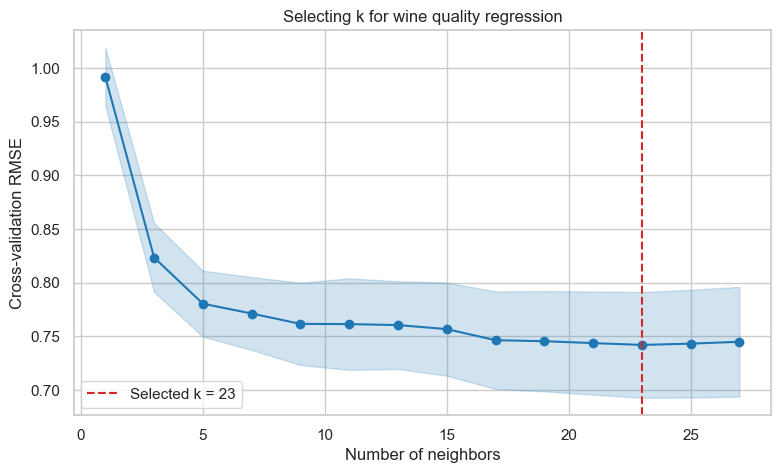

In [5]:
X_train, X_test, y_train, y_test = train_test_split(wine_X, wine_y, test_size=0.25, random_state=RANDOM_STATE)
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
k_grid = list(range(1, 28, 2))
rows = []

for k_value in k_grid:
    model = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k_value, weights="distance"))
    scores = -cross_val_score(model, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error", error_score="raise")
    rows.append({"k": k_value, "mean_rmse": scores.mean(), "std_rmse": scores.std()})
k_results = pd.DataFrame(rows)
best_k = int(k_results.loc[k_results["mean_rmse"].idxmin(), "k"])
display(k_results.sort_values("mean_rmse").head(10).round(3))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_results["k"], k_results["mean_rmse"], marker="o", color="tab:blue")
ax.fill_between(k_results["k"], k_results["mean_rmse"] - k_results["std_rmse"], k_results["mean_rmse"] + k_results["std_rmse"], alpha=0.2, color="tab:blue")
ax.axvline(best_k, color="tab:red", linestyle="--", label=f"Selected k = {best_k}")
ax.set_xlabel("Number of neighbors")
ax.set_ylabel("Cross-validation RMSE")
ax.set_title("Selecting k for wine quality regression")
ax.legend()
plt.show()

## ۲. هموارسازی را روی منحنی کنترل‌شده ببینید

مثال مصنوعی از مشاهده‌های نویزی منحنی سینوسی استفاده می‌کند. با K=1، پیش‌بینی شکل ناهموار دارد و نقطه‌های منفرد را دنبال می‌کند. با K متوسط، منحنی الگوی اصلی را دنبال و نویز را حذف می‌کند. با K بزرگ، برآورد بسیار هموار می‌شود و نوسان را تخت می‌کند.

این شهود دیداری به دادهٔ واقعی منتقل می‌شود، هرچند فضای ویژگی واقعی بیش از یک بُعد دارد. سطح رگرسیون KNN از میانگین هدف محلی ساخته می‌شود. وقتی بهترین کار را می‌کند که نمایش فاصله مثال‌های واقعاً قابل مقایسه را بیابد و دادهٔ آموزش پیرامون هر پرس‌وجو به‌اندازهٔ کافی متراکم باشد.

In [6]:
test_rows = []
for weight_rule in ["uniform", "distance"]:
    model = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=best_k, weights=weight_rule))
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    test_rows.append({
        "weights": weight_rule,
        "MAE": mean_absolute_error(y_test, prediction),
        "RMSE": np.sqrt(mean_squared_error(y_test, prediction)),
        "R2": r2_score(y_test, prediction),
    })
test_results = pd.DataFrame(test_rows)
display(test_results.round(3))

,weights,MAE,RMSE,R2
0,uniform,0.588,0.715,0.272
1,distance,0.514,0.673,0.355


## ۳. Wine Quality را پیش از رگرسیون بررسی کنید

فایل Wine Quality اندازه‌گیری‌های شیمیایی عددی مانند acidity، sulphates، alcohol، density و pH دارد. ستون quality امتیاز صحیح است و هدف رگرسیون می‌شود. سطرهای نخست، نوع داده و آمار خلاصه پیش از مدل نمایش داده می‌شوند تا مقیاس ویژگی‌ها و دامنهٔ هدف روشن باشد.

KNN به مقیاس حساس است. Alcohol، sulphur dioxide، density و acidity واحد و دامنهٔ متفاوت دارند. StandardScaler داخل pipeline قرار می‌گیرد تا هر fold اعتبارسنجی مقیاس را فقط از سطرهای آموزش خود یاد بگیرد. این کار مانع تغییر هندسهٔ انتخاب K با اطلاعات اعتبارسنجی می‌شود.

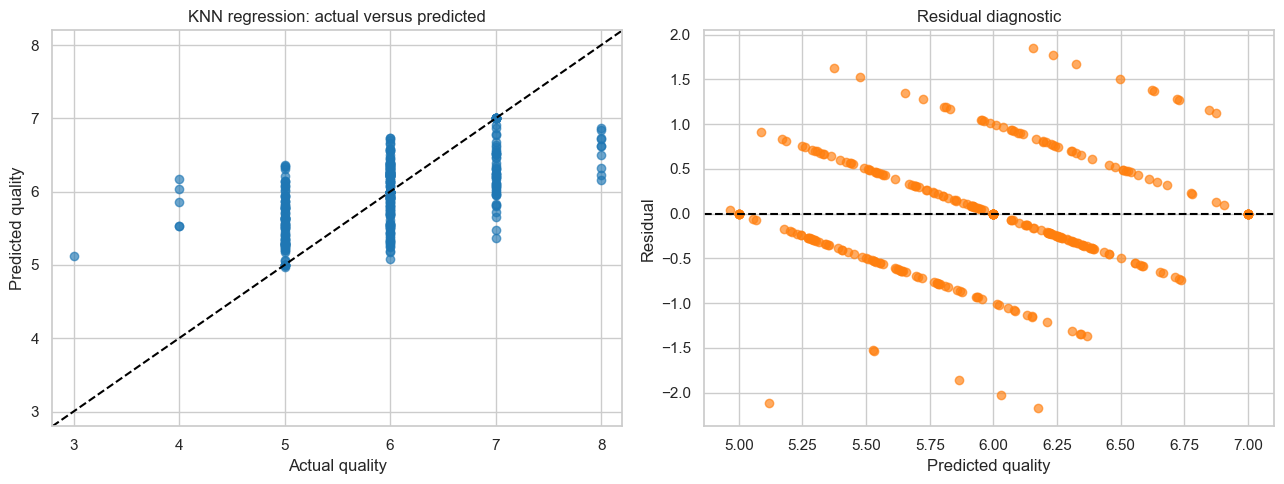

In [7]:
selected_model = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=best_k, weights="distance"))
selected_model.fit(X_train, y_train)
selected_prediction = selected_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, selected_prediction, alpha=0.65, color="tab:blue")
limits = [min(y_test.min(), selected_prediction.min()) - 0.2, max(y_test.max(), selected_prediction.max()) + 0.2]
axes[0].plot(limits, limits, linestyle="--", color="black")
axes[0].set_xlim(limits)
axes[0].set_ylim(limits)
axes[0].set_xlabel("Actual quality")
axes[0].set_ylabel("Predicted quality")
axes[0].set_title("KNN regression: actual versus predicted")
residuals = y_test - selected_prediction
axes[1].scatter(selected_prediction, residuals, alpha=0.65, color="tab:orange")
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set_xlabel("Predicted quality")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual diagnostic")
plt.tight_layout()
plt.show()

## ۴. K را با اعتبارسنجی RMSE انتخاب کنید

زیرمجموعهٔ آزمون را کنار می‌گذاریم و فقط روی سطرهای آموزش از اعتبارسنجی پنج‌تایی برای مقایسهٔ Kهای فرد استفاده می‌کنیم. RMSE ریشهٔ میانگین خطای مربع است:

$$
\text{RMSE}=\sqrt{\frac{1}{m}\sum_{j=1}^{m}(y_j-\hat{y}_j)^2}.
$$

این معیار خطاهای بزرگ را بیش از MAE جریمه می‌کند. منحنی میانگین و انحراف معیار foldها را گزارش می‌دهد. اگر مقدارهای نزدیک عملکرد مشابه دارند، کمینهٔ خیلی کوچک و تنها را قطعی ندانید. ناحیهٔ پایدار اغلب انتخاب عملی بهتری از مقدار بسیار محلیِ تنظیم‌شده است.

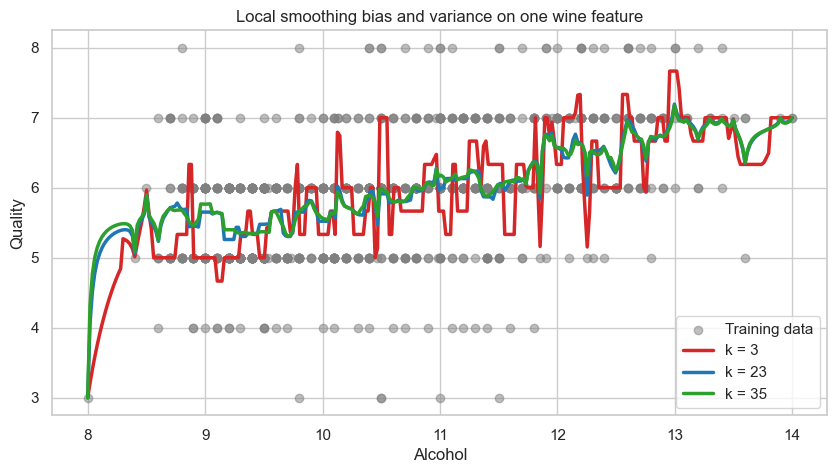

In [8]:
feature = "alcohol"
one_X = wine[[feature]]
one_y = wine["quality"]
one_train, one_test, target_train, target_test = train_test_split(one_X, one_y, test_size=0.25, random_state=RANDOM_STATE)
one_scaler = StandardScaler().fit(one_train)
one_train_scaled = one_scaler.transform(one_train)
one_grid = np.linspace(one_X[feature].min(), one_X[feature].max(), 300).reshape(-1, 1)
one_grid_scaled = one_scaler.transform(pd.DataFrame({feature: one_grid.ravel()}))

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(one_train[feature], target_train, alpha=0.5, color="gray", label="Training data")
for k_value, color in zip([3, best_k, 35], ["tab:red", "tab:blue", "tab:green"]):
    model = KNeighborsRegressor(n_neighbors=k_value, weights="distance").fit(one_train_scaled, target_train)
    ax.plot(one_grid.ravel(), model.predict(one_grid_scaled), color=color, linewidth=2.5, label=f"k = {k_value}")
ax.set_xlabel("Alcohol")
ax.set_ylabel("Quality")
ax.set_title("Local smoothing bias and variance on one wine feature")
ax.legend()
plt.show()

## ۵. وزن‌دهی، residual و محدودیت کالیبراسیون

پس از انتخاب K، وزن‌دهی یکنواخت و فاصله‌ای را روی آزمون کنارگذاشته‌شده مقایسه می‌کنیم. MAE خطای مطلق معمول را می‌گوید، RMSE خطای بزرگ را برجسته می‌کند و $R^2$ واریانس توضیح‌داده‌شده را با baseline میانگین ثابت مقایسه می‌کند. هیچ‌یک ثابت نمی‌کند پیش‌بینی برای تصمیم کالیبره است. امتیاز کیفیت مرتب و انسانی است، پس خطای یک واحد شاید همه‌جا معنای یکسان نداشته باشد.

نمودار actual-versus-predicted توافق کلی را نشان می‌دهد و residual به‌دنبال الگو است. روند residual می‌تواند نشان‌دهندهٔ ساختار غیرخطی جاافتاده، ویژگی ناکافی، نویز متغیر یا تراکم محلی ضعیف باشد. KNN هموارساز است، نه تضمین این‌که هر الگوی محلی در داده حاضر است.

In [9]:
query = X_test.iloc[[0]]
query_scaled = selected_model.named_steps["standardscaler"].transform(query)
distances, indices = selected_model.named_steps["kneighborsregressor"].kneighbors(query_scaled)
neighbors = X_train.iloc[indices[0]].copy()
neighbors["quality"] = y_train.iloc[indices[0]].to_numpy()
neighbors["distance"] = distances[0]

display(query.assign(actual_quality=y_test.iloc[0], predicted_quality=selected_prediction[0]).round(3))
display(neighbors.sort_values("distance").head(12).round(3))

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,actual_quality,predicted_quality
1178,7.3,0.51,0.26,3.3,0.09,7.0,135.0,0.994,3.01,0.52,8.8,5,4.966


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,distance
263,7.1,0.550,0.13,1.7,0.073,21.0,165.0,0.994,2.97,0.58,9.2,6,1.847
1187,7.2,0.550,0.09,1.5,0.108,16.0,151.0,0.994,3.07,0.57,9.2,4,1.891
824,7.2,0.600,0.20,9.9,0.070,21.0,174.0,0.997,3.03,0.54,9.1,5,2.438
73,7.6,0.670,0.14,1.5,0.074,25.0,168.0,0.994,3.05,0.51,9.3,5,2.446
448,7.0,0.390,0.21,10.7,0.098,13.0,91.0,0.997,3.03,0.47,9.3,5,2.485
862,7.7,0.460,0.18,3.3,0.054,18.0,143.0,0.994,3.12,0.51,10.8,6,2.585
1045,7.2,0.585,0.20,10.4,0.086,17.0,94.0,0.997,3.13,0.40,9.4,5,2.601
1146,7.2,0.615,0.10,1.4,0.068,25.0,154.0,0.995,3.20,0.48,9.7,4,2.668
11,6.7,0.540,0.28,5.4,0.060,21.0,105.0,0.995,3.27,0.37,9.0,5,2.834
214,6.4,0.680,0.26,3.4,0.069,25.0,146.0,0.993,3.18,0.40,9.3,5,2.901


## ۶. بایاس و واریانس در یک ویژگی تفسیرپذیر

برای دیدن هموارسازی، رگرسور KNN تک‌ویژگی با alcohol می‌سازیم. K بسیار کوچک با تغییر alcohol می‌تواند جهش تند داشته باشد و K بزرگ‌تر منحنی ملایم‌تری می‌سازد. این به معنی توضیح‌دادن کامل کیفیت با alcohol نیست؛ فقط نشان می‌دهد یک سازوکار میانگین‌گیری محلی با تغییر K چگونه عوض می‌شود.

بایاس و واریانس را در یک تقسیم نمی‌بینیم؛ آن‌ها رفتار مورد انتظار روی مجموعه‌داده‌های ممکن را توصیف می‌کنند. اعتبارسنجی و آزمایش تکراری شواهدی از مصالحه می‌دهند، اما عدم قطعیت را حذف نمی‌کنند. K را با اعتبارسنجی انتخاب و آزمون نهایی را برای برآورد صادقانه نگه دارید.

## ۷. شواهد محلی و محدودیت‌ها

جدول همسایه نشان می‌دهد کدام سطرهای wine بر یک پیش‌بینی اثر دارند. KNN وزن‌دار بر حسب فاصله به سطرهای نزدیک‌تر سهم بیشتر می‌دهد. این کار برای توضیح و اشکال‌زدایی مفید است، اما علیت را ثابت نمی‌کند. شیمی مشابه در ستون‌های ثبت‌شده می‌تواند روش تولید، منطقه، نگهداری یا تفاوت حسی ثبت‌نشده را پنهان کند.

رگرسیون KNN در ناحیهٔ مشاهده‌شده interpolation می‌کند و بیرون از آن extrapolation ضعیفی دارد. اگر wine جدید اندازه‌گیری بیرون از بازهٔ آموزش داشته باشد، نزدیک‌ترین مثال‌ها نیز شاید دور باشند. دادهٔ آموزش را نگه می‌دارد و برای دادهٔ بزرگ گران است. مقیاس‌بندی، انتخاب ویژگی، اعتبارسنجی، بازرسی فاصله و fallback یا پرچم عدم قطعیت در نبود همسایهٔ نزدیک، کار خوب هستند.

## ۸. تمرین‌ها و جمع‌بندی

1. جست‌وجوی K را با MAE به‌جای RMSE تکرار کنید. آیا ناحیهٔ انتخاب عوض می‌شود؟
2. رگرسیون KNN را با baseline رگرسیون خطی در تقسیم Wine Quality یکسان مقایسه کنید.
3. ستون نویز تصادفی اضافه و تغییر منحنی K را بررسی کنید.
4. radius-neighbors regressor را به‌کار ببرید و تعیین کنید وقتی همسایه‌ای در شعاع نیست چه شود.
5. residual را بر اساس سطح alcohol گرد شده گروه‌بندی و تغییر خطا در دامنهٔ ویژگی را بررسی کنید.

### جمع‌بندی

رگرسیون KNN هدف پیوسته را با هموارسازی مقدارهای هدف همسایه پیش‌بینی می‌کند. K تعادل بایاس-واریانس محلی را کنترل می‌کند: K کوچک منعطف و متغیر و K بزرگ پایدار و بایاس‌دار است. اثر را دیدیم، K را با اعتبارسنجی RMSE بدون نشت انتخاب کردیم، قانون وزن را مقایسه کردیم، residual را بررسی و شواهد محلی را بازرسی کردیم. رگرسیون KNN قابل اعتماد به فاصلهٔ معنادار، تراکم دادهٔ محلی کافی، معیار مناسب و اعتبارسنجی صادقانه وابسته است.